# 04 · Generation with a frozen Stable Diffusion (Experiment 4)
**Question:** can the fMRI-predicted representations guide a reasonable image?

Stable Diffusion, CLIP and the VAE stay **frozen**; only the small token adapter is trained. This step needs a GPU and the diffusers weights.

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do — this avoids a notebooks/data/... mismatch.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from src.utils import load_config
from src.data import FmriDataModule
from src.generation import generate_images, train_token_adapter
cfg = load_config('configs/exp04_generation_v4_f2.yaml')
#cfg['generation']['num_samples'] = 6
dm = FmriDataModule(cfg).prepare()

# Experiment name
print(cfg['experiment']['name'])

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion
14:26:12 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
14:26:12 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}
exp04_generation_v4_f2


In [2]:
print(cfg['generation']['mode'])
print(cfg['generation']['sd_model'])
print(cfg['generation']['adapter_scheduler']) #nuevo del exp 04_...2_1v2
print(cfg['generation']['adapter_warmup_ratio']) #nuevo del exp 04_...2_1v2
print(cfg['generation']['adapter_batch_size']) # distinto, antes era 4
print(cfg['training']['early_stopping_patience'])
print(cfg['generation']['guidance_scale'])
print(cfg['generation']['adapter_timesteps_per_sample'])
print(cfg['generation']['adapter_eval_enabled'])
print(cfg['generation']['adapter_eval_every_n_epochs'])

adapter_lowlevel
stable-diffusion-v1-5/stable-diffusion-v1-5
cosine
0.05
8
10
3.0
1
True
2


In [3]:
# (Optional) train the token adapter — the only trainable module.
TRAIN_ADAPTER = True
adapter_ckpt = None
if TRAIN_ADAPTER:
    cfg['generation']['adapter_epochs'] = 20
    info = train_token_adapter(cfg, dm, resume='auto')
    adapter_ckpt = info['adapter_checkpoint']
    print(adapter_ckpt)

c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 4/4 [00:00<00:00, 43.71it/s]
c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this meth

11:59:07 | INFO    | clip | Loaded open_clip ViT-L-14/openai (dim=768)
11:59:07 | INFO    | sd | Adapter training: 1 timestep(s)/sample | select best by 'clip_sim' | eval on
12:32:21 | INFO    | sd | [adapter] epoch 0/20 loss 0.15878 clip_sim 0.6848 (1994s) *
13:05:06 | INFO    | sd | [adapter] epoch 1/20 loss 0.15851 (1964s)
13:38:03 | INFO    | sd | [adapter] epoch 2/20 loss 0.15722 clip_sim 0.7388 (1975s) *
14:10:59 | INFO    | sd | [adapter] epoch 3/20 loss 0.15822 (1975s)
14:43:57 | INFO    | sd | [adapter] epoch 4/20 loss 0.15866 clip_sim 0.7471 (1977s) *
15:16:38 | INFO    | sd | [adapter] epoch 5/20 loss 0.15688 (1958s)
15:49:38 | INFO    | sd | [adapter] epoch 6/20 loss 0.15786 clip_sim 0.7479 (1979s) *
16:22:13 | INFO    | sd | [adapter] epoch 7/20 loss 0.15531 (1953s)
16:55:39 | INFO    | sd | [adapter] epoch 8/20 loss 0.15755 clip_sim 0.7476 (2005s)
17:28:28 | INFO    | sd | [adapter] epoch 9/20 loss 0.15854 (1968s)
18:01:13 | INFO    | sd | [adapter] epoch 10/20 loss 0.159

In [4]:
#ejecutar esto si ya habíamos entrenado y queremos cargar sin reentrenar
TRAIN_ADAPTER = False
adapter_ckpt = None

In [11]:
print(adapter_ckpt)

outputs/exp04_generation_v3/checkpoints/adapter_best.pt


In [3]:
#adapter_ckpt = 'outputs/exp04_generation/checkpoints/adapter_last.pt'
#adapter_ckpt = 'outputs/exp04_generation/checkpoints/adapter_best.pt'
#adapter_ckpt = 'outputs/exp04_generation_sd21/checkpoints/adapter_best.pt'
#adapter_ckpt = 'outputs/exp04_generation_sd21_v2/checkpoints/adapter_best.pt'

#adapter_ckpt = 'outputs/exp04_generation_v4_f1/checkpoints/adapter_best.pt'
adapter_ckpt = 'outputs/exp04_generation_v4_f2/checkpoints/epoch_0001.pt'

In [4]:
decoder = 'outputs/exp03_lowlevel_multitask/checkpoints/best.pt'
#decoder = 'outputs/exp03_lowlevel_multitask_sd21/checkpoints/best.pt'
#outputs = generate_images(cfg, decoder, adapter_checkpoint=adapter_ckpt, conditions=['correct'], split='test')
outputs = generate_images(cfg, decoder, adapter_checkpoint=adapter_ckpt, split='test')
len(outputs['correct'])

14:26:23 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv


14:26:23 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 4/4 [00:02<00:00,  1.34it/s]
c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


14:26:36 | INFO    | sd | Loaded token adapter from outputs/exp04_generation_v4_f2/checkpoints/epoch_0001.pt
14:28:03 | INFO    | generate | Generated 16 images for condition 'correct'
14:29:28 | INFO    | generate | Generated 16 images for condition 'permuted'
14:30:54 | INFO    | generate | Generated 16 images for condition 'zero'


16

## Real vs generated (correct fMRI)

In [9]:
%matplotlib inline

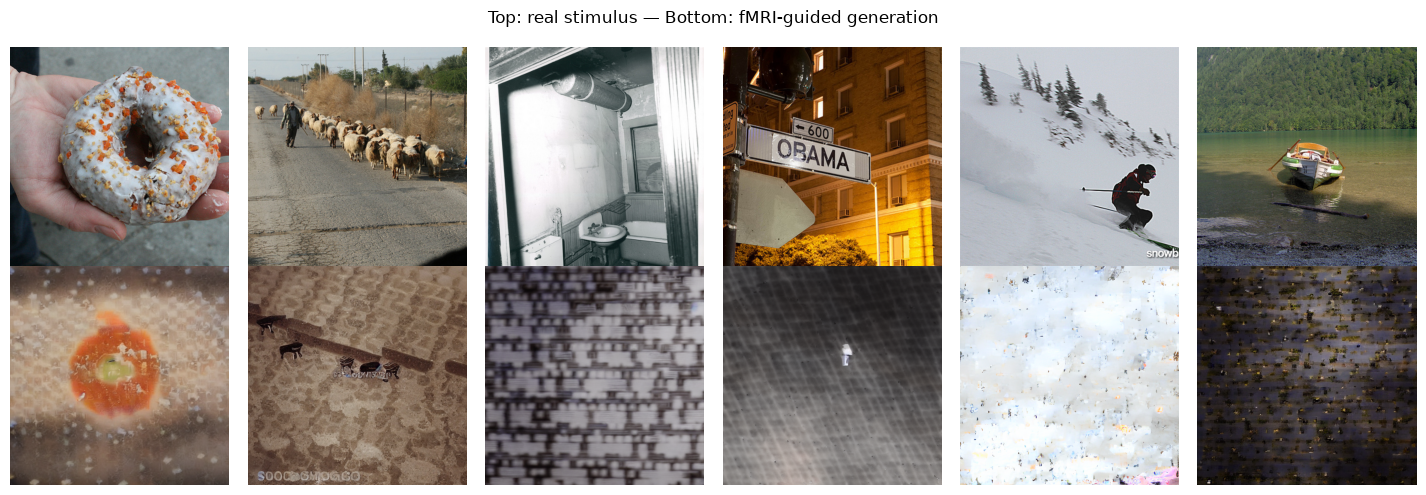

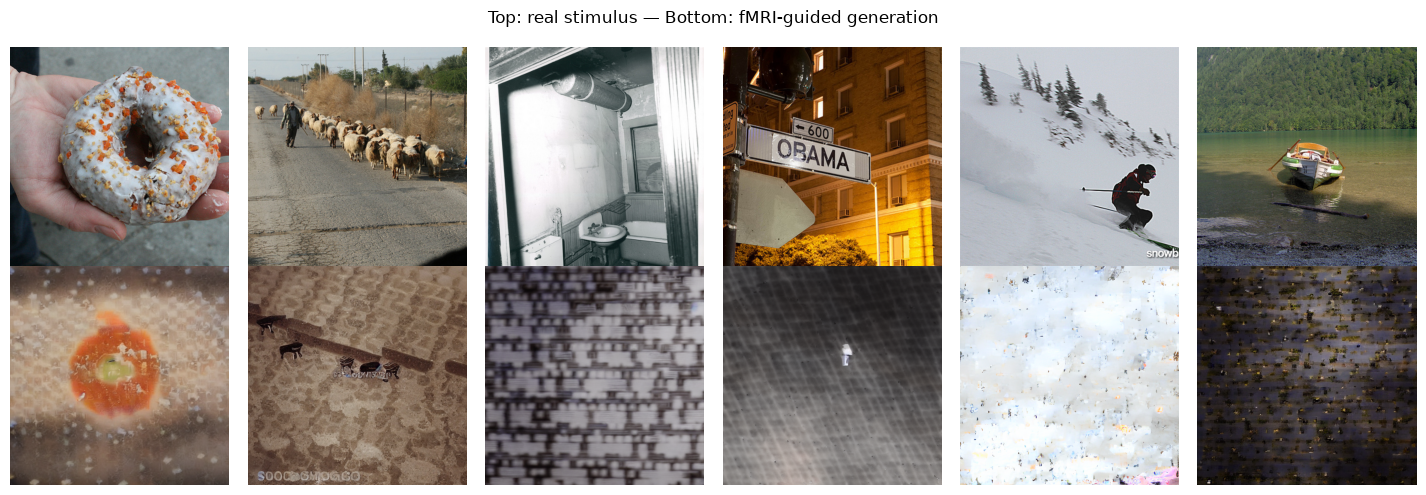

In [10]:
n = min(6, len(outputs['image_ids']))
fig, axes = plt.subplots(2, n, figsize=(2.4*n, 5))
for j in range(n):
    axes[0,j].imshow(outputs['real'][j]); axes[0,j].axis('off')
    axes[1,j].imshow(outputs['correct'][j]); axes[1,j].axis('off')
axes[0,0].set_ylabel('real'); axes[1,0].set_ylabel('generated')
plt.suptitle('Top: real stimulus — Bottom: fMRI-guided generation'); plt.tight_layout(); plt.show()

In [11]:
from src.utils import load_json, get_experiment_paths
load_json(get_experiment_paths(cfg, ensure=False).metadata / 'generation_params.json')

{'mode': 'adapter_lowlevel',
 'conditions': ['correct', 'permuted', 'zero'],
 'split': 'test',
 'num_samples': 16,
 'generation_seed': 123,
 'sample_seed': 42,
 'guidance_scale': 3.0,
 'num_inference_steps': 50,
 'strength': 0.8,
 'sd_model': 'stable-diffusion-v1-5/stable-diffusion-v1-5',
 'prompt_mode': 'empty',
 'decoder_checkpoint': 'outputs/exp03_lowlevel_multitask/checkpoints/best.pt',
 'adapter_checkpoint': 'outputs\\exp04_generation\\checkpoints\\adapter_best.pt',
 'image_ids': ['test-0013_nsd-05427',
  'test-0015_nsd-06223',
  'test-0031_nsd-16539',
  'test-0065_nsd-32839',
  'test-0082_nsd-38997',
  'test-0096_nsd-46100',
  'test-0106_nsd-51308',
  'test-0113_nsd-53861',
  'test-0114_nsd-54675',
  'test-0115_nsd-54824',
  'test-0120_nsd-56600',
  'test-0125_nsd-59091',
  'test-0128_nsd-59474',
  'test-0148_nsd-68380',
  'test-0150_nsd-69606',
  'test-0152_nsd-69967']}

**Takeaway:** generation is exploratory here; the quantitative claim comes from the ablation comparison in notebook 05.